In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray # handles HOG feature extraction
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [6]:
# Load metadata
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# Build image path lookup
image_dir_1 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
image_dir_2 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

image_paths = {}
for fname in os.listdir(image_dir_1):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_1, fname)
for fname in os.listdir(image_dir_2):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_2, fname)

print(f"Metadata rows: {len(df)}")
print(f"Images indexed: {len(image_paths)}")

Metadata rows: 10015
Images indexed: 10015


In [9]:
# Feature extraction function
def extract_features(image_id, image_paths):

    img_path = image_paths.get(image_id)

    img = Image.open(img_path).resize((64, 64))  # smaller size for SVM speed
    img_array = np.array(img)

    # HOG features - captures shape and edge structure
    gray = rgb2gray(img_array)

    hog_features = hog(
        gray,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    # Colour histogram features - captures colour distribution
    hist_r = np.histogram(
        img_array[:, :, 0],
        bins=32,
        range=(0, 256)
    )[0]

    hist_g = np.histogram(
        img_array[:, :, 1],
        bins=32,
        range=(0, 256)
    )[0]

    hist_b = np.histogram(
        img_array[:, :, 2],
        bins=32,
        range=(0, 256)
    )[0]

    colour_features = np.concatenate([hist_r, hist_g, hist_b])

    # Combine both feature types
    feature_vector = np.concatenate([hog_features, colour_features])

    return feature_vector


# Test on a single image first
sample_id = df['image_id'].iloc[0]

sample_features = extract_features(sample_id, image_paths)

print(f"Feature vector length for one image: {len(sample_features)}")
print(f"Feature vector shape: {sample_features.shape}")

# Optional: show first few values
print("\nFirst 10 features:")
print(sample_features[:10])

print("\nFeature extraction function working correctly")

Feature vector length for one image: 1664
Feature vector shape: (1664,)

First 10 features:
[0.11960383 0.13600987 0.11456898 0.12717123 0.24748233 0.07322089
 0.07962707 0.14177987 0.24748233 0.13641858]

Feature extraction function working correctly


##### 1568 HOG features + 96 Color histogram features = 1664 total features
Each image was resized to 64×64 pixels and transformed into a 1664-dimensional feature vector. The feature vector consisted of 1568 Histogram of Oriented Gradients (HOG) features capturing texture and edge information, and 96 color histogram features representing color distribution across RGB channels. This numerical representation enabled the SVM classifier to learn patterns associated with different skin lesion classes.

In [10]:
# Extract features for ALL 10,015 images
# Warning: this will take 5-10 minutes - normal, don't panic

print("Starting feature extraction for all images...")
print("This will take around 5-10 minutes, please wait...\n")

features = []
labels = []
failed = 0

for idx, row in df.iterrows():
    try:
        feat = extract_features(row['image_id'], image_paths)
        features.append(feat)
        labels.append(row['dx'])
    except Exception as e:
        failed += 1
        continue
    
    # Progress update every 1000 images
    if (idx + 1) % 1000 == 0:
        print(f"  Processed {idx + 1}/10015 images...")

X = np.array(features)
y = np.array(labels)

print(f"\nDone!")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Failed images: {failed}")

Starting feature extraction for all images...
This will take around 5-10 minutes, please wait...

  Processed 1000/10015 images...
  Processed 2000/10015 images...
  Processed 3000/10015 images...
  Processed 4000/10015 images...
  Processed 5000/10015 images...
  Processed 6000/10015 images...
  Processed 7000/10015 images...
  Processed 8000/10015 images...
  Processed 9000/10015 images...
  Processed 10000/10015 images...

Done!
Feature matrix shape: (10015, 1664)
Labels shape: (10015,)
Failed images: 0


It loops through all 10,015 images and extracts the 1664 feature vector from each and every image.
x is a matrix of shape (10015,1664)....where every row is an image and every column is a feature 
y is the array of 10,015 labels (SVM will train on this)

In [11]:
# Encode labels, split data, scale features
# Step 1: Convert text labels to numbers (SVM needs numbers not strings)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")
print(f"Encoded as: {list(range(len(le.classes_)))}\n")

# Step 2: Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded  # ensures class balance is maintained in both splits
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}\n")

# Step 3: Scale features (SVM is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use same scaler, don't fit again on test
print("Features scaled successfully")
print(f"Mean of first feature after scaling: {X_train_scaled[:,0].mean():.4f} (should be ~0)")

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Encoded as: [0, 1, 2, 3, 4, 5, 6]

Training samples: 8012
Testing samples:  2003

Features scaled successfully
Mean of first feature after scaling: -0.0000 (should be ~0)


1) label encoder converts textual labels to numerical values so that SVM can work on it
2) The data is divided in 80% for training(8012 images) and 20% for testing(2003 images) 
3) The stratify parameter is important as it ensures the 67%/33% class ratio is preserved in both splits, so your test set isn't accidentally all nv images
4) StandardScaler rescales all 1664 features to have mean=0 and standard deviation=1.


In [12]:
# Train the SVM model
# Warning: this will take 10-15 minutes - normal

from sklearn.svm import SVC
import time

print("Training SVM model...")
print("Expected time: 10-15 minutes, please wait...\n")

start = time.time()

svm_model = SVC(
    kernel='rbf',        # RBF kernel works best for image features
    C=10,                # regularization - how hard the model tries to fit training data
    gamma='scale',       # how far the influence of a single training example reaches
    class_weight='balanced',  # automatically handles class imbalance
    random_state=42,
    verbose=True         # prints progress
)

svm_model.fit(X_train_scaled, y_train)

end = time.time()
print(f"\nTraining complete in {(end-start)/60:.1f} minutes")

Training SVM model...
Expected time: 10-15 minutes, please wait...

[LibSVM].*.*
optimization finished, #iter = 1527
obj = -448.892165, rho = 0.952070
nSV = 642, nBSV = 0
.*.*
optimization finished, #iter = 2007
obj = -530.708692, rho = 0.865871
nSV = 859, nBSV = 0
.*
optimization finished, #iter = 609
obj = -156.588151, rho = -0.268694
nSV = 300, nBSV = 0
.*
optimization finished, #iter = 1598
obj = -389.283572, rho = 0.844644
nSV = 732, nBSV = 0
.*.*
optimization finished, #iter = 2417
obj = -519.167423, rho = 2.001103
nSV = 1088, nBSV = 24
.*
optimization finished, #iter = 555
obj = -105.571157, rho = 0.910715
nSV = 296, nBSV = 0
.*.*
optimization finished, #iter = 2567
obj = -707.373288, rho = 0.517395
nSV = 1096, nBSV = 0
.*
optimization finished, #iter = 846
obj = -193.087641, rho = -0.711888
nSV = 419, nBSV = 0
.*.*
optimization finished, #iter = 2235
obj = -537.821449, rho = 0.673275
nSV = 1009, nBSV = 0
..*.*
optimization finished, #iter = 3837
obj = -848.899921, rho = 1.71292

1) kernal used here is radial basis function:- it maps all the 1664 featues into a higher dimansional space so that SVM can find a boundary between the classes
2) C=10:- Controls how strictly the model tries to correctly classify every training point. Higher C = stricter = risks overfitting. 10 is a reasonable starting value
3) class_weight='balanced':— Automatically gives higher penalty to mistakes on minority classes like df (115 images) and vasc (142 images)
4) verbose=True — Prints progress updates so you know it's running and not frozen.


In [13]:
# Evaluate the SVM model
y_pred = svm_model.predict(X_test_scaled)

# Overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc*100:.2f}%\n")

# Per class accuracy - this is the important on
print("Per-Class Performance:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 73.14%

Per-Class Performance:
              precision    recall  f1-score   support

       akiec       0.39      0.32      0.35        65
         bcc       0.42      0.32      0.36       103
         bkl       0.45      0.34      0.39       220
          df       1.00      0.09      0.16        23
         mel       0.55      0.25      0.35       223
          nv       0.80      0.95      0.87      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.73      2003
   macro avg       0.52      0.33      0.35      2003
weighted avg       0.69      0.73      0.69      2003



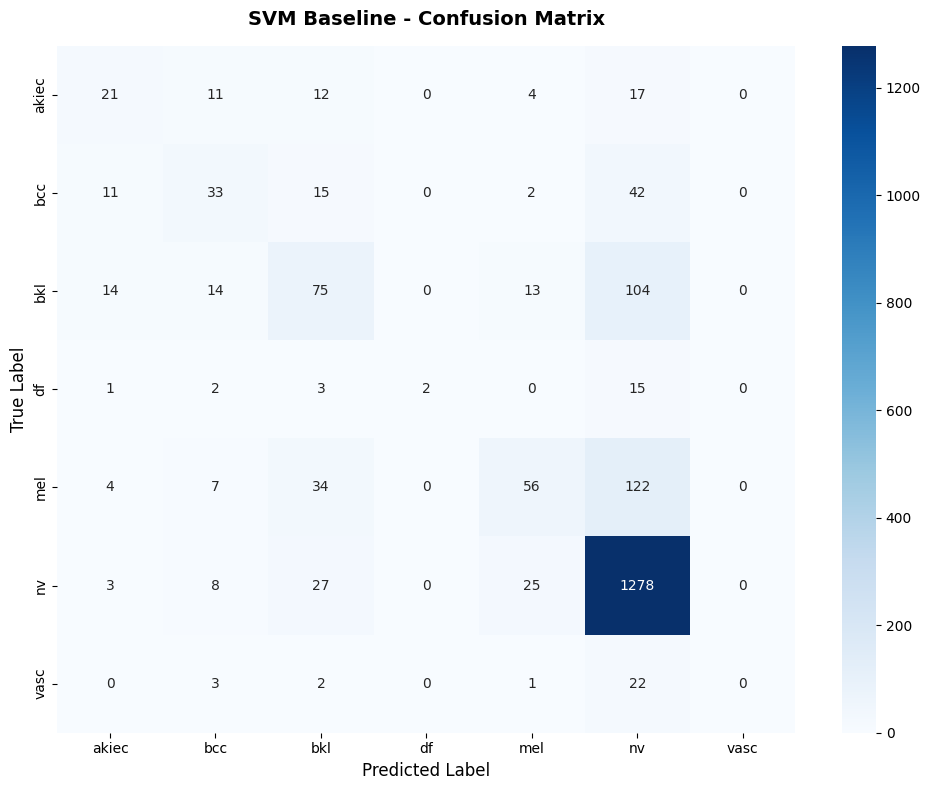

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('SVM Baseline - Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save baseline results summary
results_summary = {
    'model': 'SVM (HOG + Colour Histogram)',
    'overall_accuracy': 73.14,
    'macro_avg_f1': 0.35,
    'melanoma_recall': 25.1,
    'vasc_recall': 0.0,
    'df_recall': 8.7
}

import json
with open('svm_baseline_results.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("Results saved. SVM Baseline complete.")

Results saved. SVM Baseline complete.
